**Jakub Orchowski, s223281**

# CEL ĆWICZENIA
Implementacja modeli oświetlenia Lamberta i Phonga oraz technik cieniowania dla sceny złożonej z czterech ścian bocznych ostrosłupa rzutowanego równolegle na płaszczyznę XY.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# Zadania

## Zadanie 1.
Generuję obraz sceny złożonej z czterech trójkątów przy użyciu modelu oświetlenia Lamberta.
Całość liczę jednym pipeline'em: najpierw wyznaczam próbki pikseli należących do każdego trójkąta, potem buduję z-bufor widoczności, a jasność każdego widocznego piksela obliczam z prawa Lamberta z uwzględnieniem tłumienia odległości od źródła.

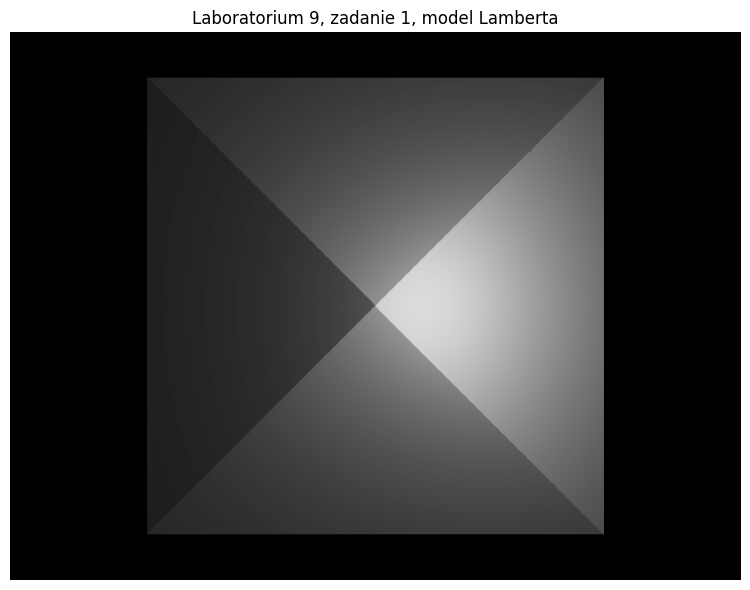

Model Lamberta: min = 29.48, max = 219.15, średnia = 86.06, liczba widocznych pikseli = 160000


In [2]:
from dataclasses import dataclass

IMAGE_WIDTH = 640
IMAGE_HEIGHT = 480
PIXEL_SIZE = 0.1
AMBIENT_INTENSITY = 20.0
POINT_LIGHT_INTENSITY = 235.0
ATTENUATION_ALPHA = 0.001
SURFACE_REFLECTANCE = 1.0
LIGHT_POSITION = np.array([10.0, 0.0, 0.0], dtype=np.float64)
EYE_POSITION = np.array([65.0, 0.0, 0.0], dtype=np.float64)
PHONG_SHININESS = 15.0

VERTICES = np.array(
    [
        [0.0, 0.0, 10.0],
        [20.0, 20.0, 20.0],
        [20.0, -20.0, 20.0],
        [-20.0, -20.0, 20.0],
        [-20.0, 20.0, 20.0],
    ],
    dtype=np.float64,
)
TRIANGLE_INDICES = np.array(
    [
        [0, 1, 2],
        [0, 2, 3],
        [0, 3, 4],
        [0, 4, 1],
    ],
    dtype=np.int32,
)


@dataclass(frozen=True)
class TriangleSamples:
    indices: np.ndarray
    vertices: np.ndarray
    face_normal: np.ndarray
    pixel_x: np.ndarray
    pixel_y: np.ndarray
    weights: np.ndarray
    points: np.ndarray
    depths: np.ndarray


@dataclass(frozen=True)
class RenderResult:
    image: np.ndarray
    visible_mask: np.ndarray


def create_coordinate_axes(width: int, height: int, pixel_size: float) -> tuple[np.ndarray, np.ndarray]:
    """Tworzy współrzędne środków pikseli dla obrazu o zadanym rozmiarze."""
    x_coordinates = (np.arange(width) + 0.5 - width / 2.0) * pixel_size
    y_coordinates = (height / 2.0 - (np.arange(height) + 0.5)) * pixel_size
    return x_coordinates, y_coordinates



def barycentric_inverse(projected_vertices: np.ndarray) -> np.ndarray:
    """Przygotowuje macierz odwrotną do szybkiego liczenia wag barycentrycznych."""
    return np.linalg.inv(np.vstack((projected_vertices.T, np.ones(3))))



def face_normal(vertices: np.ndarray) -> np.ndarray:
    """Wyznacza znormalizowany wektor normalny skierowany do obserwatora."""
    normal = np.cross(vertices[1] - vertices[0], vertices[2] - vertices[0])
    normal = normal / np.linalg.norm(normal)
    if normal[2] > 0.0:
        normal = -normal
    return normal



def point_light_factor(distances: np.ndarray) -> np.ndarray:
    """Wyznacza tłumienie światła punktowego zależne od odległości."""
    return 1.0 / (1.0 + ATTENUATION_ALPHA * distances * distances)



def lambert_intensity(points: np.ndarray, normals: np.ndarray, light_position: np.ndarray) -> np.ndarray:
    """Oblicza jasności punktów zgodnie z modelem Lamberta."""
    light_vectors = light_position - points
    distances = np.linalg.norm(light_vectors, axis=1)
    safe_distances = np.where(distances == 0.0, 1.0, distances)
    light_directions = light_vectors / safe_distances[:, None]
    cosines = np.clip(np.sum(normals * light_directions, axis=1), 0.0, None)
    diffuse = POINT_LIGHT_INTENSITY * SURFACE_REFLECTANCE * cosines * point_light_factor(safe_distances)
    return AMBIENT_INTENSITY * SURFACE_REFLECTANCE + diffuse



def phong_intensity(
    points: np.ndarray,
    normals: np.ndarray,
    light_position: np.ndarray,
    eye_position: np.ndarray,
    shininess: float,
) -> np.ndarray:
    """Oblicza jasności punktów zgodnie z modelem odbicia Phonga."""
    light_vectors = light_position - points
    light_distances = np.linalg.norm(light_vectors, axis=1)
    safe_light_distances = np.where(light_distances == 0.0, 1.0, light_distances)
    light_directions = light_vectors / safe_light_distances[:, None]
    diffuse_cosines = np.clip(np.sum(normals * light_directions, axis=1), 0.0, None)
    diffuse = POINT_LIGHT_INTENSITY * SURFACE_REFLECTANCE * diffuse_cosines

    view_vectors = eye_position - points
    view_distances = np.linalg.norm(view_vectors, axis=1)
    safe_view_distances = np.where(view_distances == 0.0, 1.0, view_distances)
    view_directions = view_vectors / safe_view_distances[:, None]

    reflection_directions = 2.0 * diffuse_cosines[:, None] * normals - light_directions
    reflection_norms = np.linalg.norm(reflection_directions, axis=1)
    safe_reflection_norms = np.where(reflection_norms == 0.0, 1.0, reflection_norms)
    reflection_directions = reflection_directions / safe_reflection_norms[:, None]
    specular_cosines = np.clip(np.sum(reflection_directions * view_directions, axis=1), 0.0, None)
    specular = POINT_LIGHT_INTENSITY * np.where(diffuse_cosines > 0.0, specular_cosines**shininess, 0.0)

    return AMBIENT_INTENSITY * SURFACE_REFLECTANCE + (diffuse + specular) * point_light_factor(safe_light_distances)



def build_triangle_samples(x_coordinates: np.ndarray, y_coordinates: np.ndarray) -> list[TriangleSamples]:
    """Przygotowuje próbki wszystkich pikseli należących do każdego trójkąta."""
    triangle_samples: list[TriangleSamples] = []

    for indices in TRIANGLE_INDICES:
        triangle_vertices = VERTICES[indices]
        inverse_matrix = barycentric_inverse(triangle_vertices[:, :2])
        x_min, x_max = triangle_vertices[:, 0].min(), triangle_vertices[:, 0].max()
        y_min, y_max = triangle_vertices[:, 1].min(), triangle_vertices[:, 1].max()

        x_indices = np.where((x_coordinates >= x_min - PIXEL_SIZE) & (x_coordinates <= x_max + PIXEL_SIZE))[0]
        y_indices = np.where((y_coordinates >= y_min - PIXEL_SIZE) & (y_coordinates <= y_max + PIXEL_SIZE))[0]
        pixel_x_grid, pixel_y_grid = np.meshgrid(x_indices, y_indices)
        candidate_points = np.column_stack(
            (
                x_coordinates[pixel_x_grid.ravel()],
                y_coordinates[pixel_y_grid.ravel()],
                np.ones(pixel_x_grid.size),
            )
        )
        weights = (inverse_matrix @ candidate_points.T).T
        inside_mask = np.min(weights, axis=1) >= -1e-9

        pixel_x = pixel_x_grid.ravel()[inside_mask]
        pixel_y = pixel_y_grid.ravel()[inside_mask]
        pixel_weights = weights[inside_mask]
        points = pixel_weights @ triangle_vertices
        depths = points[:, 2]

        triangle_samples.append(
            TriangleSamples(
                indices=indices,
                vertices=triangle_vertices,
                face_normal=face_normal(triangle_vertices),
                pixel_x=pixel_x,
                pixel_y=pixel_y,
                weights=pixel_weights,
                points=points,
                depths=depths,
            )
        )

    return triangle_samples



def compute_smoothed_vertex_normals(triangle_samples: list[TriangleSamples]) -> np.ndarray:
    """Uśrednia normalne ścian spotykających się w tych samych wierzchołkach."""
    normals = np.zeros_like(VERTICES)
    counts = np.zeros(len(VERTICES), dtype=np.int32)

    for triangle in triangle_samples:
        for vertex_index in triangle.indices:
            normals[vertex_index] += triangle.face_normal
            counts[vertex_index] += 1

    norms = np.linalg.norm(normals, axis=1, keepdims=True)
    norms = np.where(norms == 0.0, 1.0, norms)
    return normals / norms



def render_scene(
    triangle_samples: list[TriangleSamples],
    light_position: np.ndarray,
    shading_mode: str,
    lighting_model: str = "lambert",
    corner_normals: list[np.ndarray] | None = None,
    eye_position: np.ndarray | None = None,
    shininess: float | None = None,
) -> RenderResult:
    """Renderuje scenę dla wybranego modelu oświetlenia i cieniowania."""
    image = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.float64)
    z_buffer = np.full((IMAGE_HEIGHT, IMAGE_WIDTH), np.inf, dtype=np.float64)
    visible_mask = np.zeros((IMAGE_HEIGHT, IMAGE_WIDTH), dtype=bool)

    for triangle_position, triangle in enumerate(triangle_samples):
        pixel_y = triangle.pixel_y
        pixel_x = triangle.pixel_x
        points = triangle.points
        depths = triangle.depths
        weights = triangle.weights
        normal = triangle.face_normal

        if shading_mode == "flat":
            centroid = np.mean(triangle.vertices, axis=0, keepdims=True)
            intensities = np.full(points.shape[0], lambert_intensity(centroid, normal[None, :], light_position)[0])
        elif shading_mode == "per_pixel_face":
            normals = np.repeat(normal[None, :], points.shape[0], axis=0)
            if lighting_model == "phong":
                intensities = phong_intensity(points, normals, light_position, eye_position, shininess)
            else:
                intensities = lambert_intensity(points, normals, light_position)
        elif shading_mode == "gouraud":
            vertex_intensities = lambert_intensity(triangle.vertices, corner_normals[triangle_position], light_position)
            intensities = weights @ vertex_intensities
        elif shading_mode == "phong":
            interpolated_normals = weights @ corner_normals[triangle_position]
            interpolated_norms = np.linalg.norm(interpolated_normals, axis=1, keepdims=True)
            interpolated_norms = np.where(interpolated_norms == 0.0, 1.0, interpolated_norms)
            interpolated_normals = interpolated_normals / interpolated_norms
            intensities = lambert_intensity(points, interpolated_normals, light_position)
        else:
            raise ValueError(f"Nieznany tryb cieniowania: {shading_mode}")

        closer_mask = depths < z_buffer[pixel_y, pixel_x]
        image[pixel_y[closer_mask], pixel_x[closer_mask]] = np.clip(intensities[closer_mask], 0.0, 255.0)
        z_buffer[pixel_y[closer_mask], pixel_x[closer_mask]] = depths[closer_mask]
        visible_mask[pixel_y[closer_mask], pixel_x[closer_mask]] = True

    return RenderResult(image=image, visible_mask=visible_mask)



def summarize_render(label: str, result: RenderResult) -> None:
    """Wypisuje podstawowe statystyki wygenerowanego obrazu."""
    visible_pixels = result.image[result.visible_mask]
    print(
        f"{label}: min = {visible_pixels.min():.2f}, max = {visible_pixels.max():.2f}, "
        f"średnia = {visible_pixels.mean():.2f}, liczba widocznych pikseli = {visible_pixels.size}"
    )



def show_render(result: RenderResult, title: str) -> None:
    """Wyświetla pojedynczy obraz w skali szarości."""
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(result.image, cmap="gray", vmin=0, vmax=255)
    ax.set_title(title)
    ax.axis("off")
    plt.tight_layout()
    plt.show()


X_COORDINATES, Y_COORDINATES = create_coordinate_axes(IMAGE_WIDTH, IMAGE_HEIGHT, PIXEL_SIZE)
TRIANGLE_SAMPLES = build_triangle_samples(X_COORDINATES, Y_COORDINATES)
SMOOTH_VERTEX_NORMALS = compute_smoothed_vertex_normals(TRIANGLE_SAMPLES)
ORIGINAL_CORNER_NORMALS = [np.repeat(triangle.face_normal[None, :], 3, axis=0) for triangle in TRIANGLE_SAMPLES]
SMOOTH_CORNER_NORMALS = [SMOOTH_VERTEX_NORMALS[triangle.indices] for triangle in TRIANGLE_SAMPLES]

lab9_lambert_result = render_scene(
    TRIANGLE_SAMPLES,
    light_position=LIGHT_POSITION,
    shading_mode="per_pixel_face",
    lighting_model="lambert",
)
show_render(lab9_lambert_result, "Laboratorium 9, zadanie 1, model Lamberta")
summarize_render("Model Lamberta", lab9_lambert_result)

### Wnioski
W modelu Lamberta każda ściana zachowuje stałą normalną, ale jasność nadal zmienia się wewnątrz wielokąta, bo zależy od położenia względem źródła i od tłumienia odległości.
Z-bufor poprawnie wybiera najbliższą ścianę dla każdego piksela, dlatego w obszarach nakładania projekcji nie pojawiają się artefakty widoczności.

## Zadanie 2.
Dla tej samej sceny stosuję model odbicia Phonga z parametrem m równym 15 i położeniem oka obserwatora [65, 0, 0].
Widoczność pozostaje liczona identycznie jak w zadaniu 1, a zmienia się jedynie lokalny model oświetlenia przez dodanie składowej lustrzanej zależnej od kierunku obserwacji.

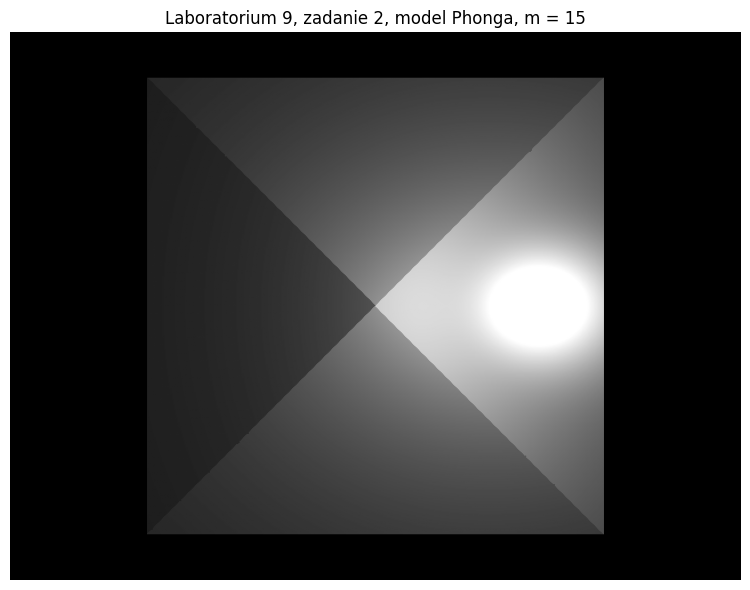

Model Phonga, m = 15: min = 29.48, max = 255.00, średnia = 93.27, liczba widocznych pikseli = 160000


In [3]:
lab9_phong_result = render_scene(
    TRIANGLE_SAMPLES,
    light_position=LIGHT_POSITION,
    shading_mode="per_pixel_face",
    lighting_model="phong",
    eye_position=EYE_POSITION,
    shininess=PHONG_SHININESS,
)
show_render(lab9_phong_result, "Laboratorium 9, zadanie 2, model Phonga, m = 15")
summarize_render("Model Phonga, m = 15", lab9_phong_result)

### Wnioski
Model Phonga dodaje lokalne refleksy zależne od położenia obserwatora, dlatego na powierzchni pojawiają się wyraźniejsze maksima jasności niż w wersji Lambertowskiej.
Dla stałych normalnych ścian połysk pozostaje związany z orientacją całych trójkątów, ale jego położenie nadal zmienia się wraz z geometrią i odległością od źródła.

## Zadanie 3.
Generuję obraz sceny z cieniowaniem stałym, wyznaczając jedną jasność dla każdej ściany na podstawie środka trójkąta.
Do obliczenia jasności wykorzystuję model Lamberta, więc każda ściana otrzymuje jedną stałą wartość zapisaną następnie we wszystkich swoich pikselach.

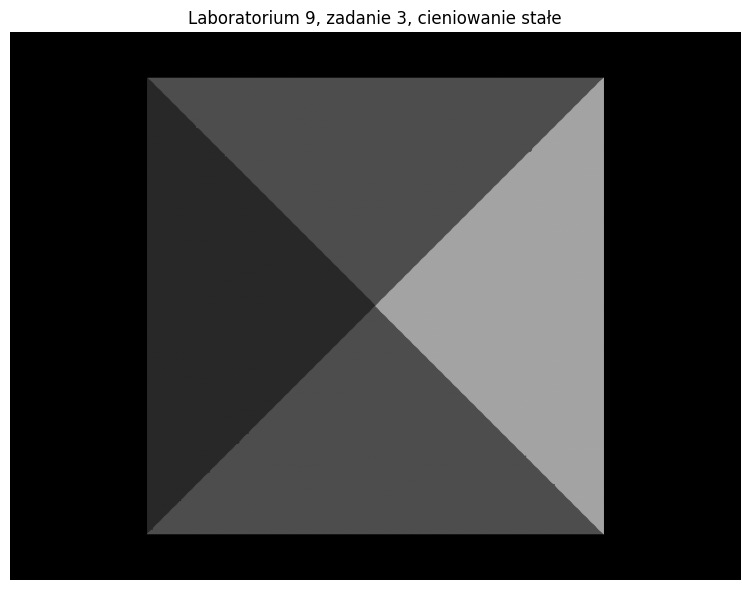

Cieniowanie stałe: min = 40.11, max = 163.92, średnia = 89.78, liczba widocznych pikseli = 160000


In [4]:
lab9_flat_result = render_scene(
    TRIANGLE_SAMPLES,
    light_position=LIGHT_POSITION,
    shading_mode="flat",
    lighting_model="lambert",
)
show_render(lab9_flat_result, "Laboratorium 9, zadanie 3, cieniowanie stałe")
summarize_render("Cieniowanie stałe", lab9_flat_result)

### Wnioski
Cieniowanie stałe upraszcza obraz do jednej jasności na ścianę, dlatego granice między trójkątami stają się bardzo wyraźne.
To podejście dobrze pokazuje orientację ścian, ale nie odwzorowuje płynnych zmian natężenia światła wewnątrz powierzchni.

## Zadanie 4.
Generuję obraz z cieniowaniem Gourauda, zachowując dla każdego narożnika trójkąta jego pierwotną normalną ściany.
Jasność obliczam w wierzchołkach modelem Lamberta, a następnie interpoluję wartości wewnątrz trójkąta metodą barycentryczną.

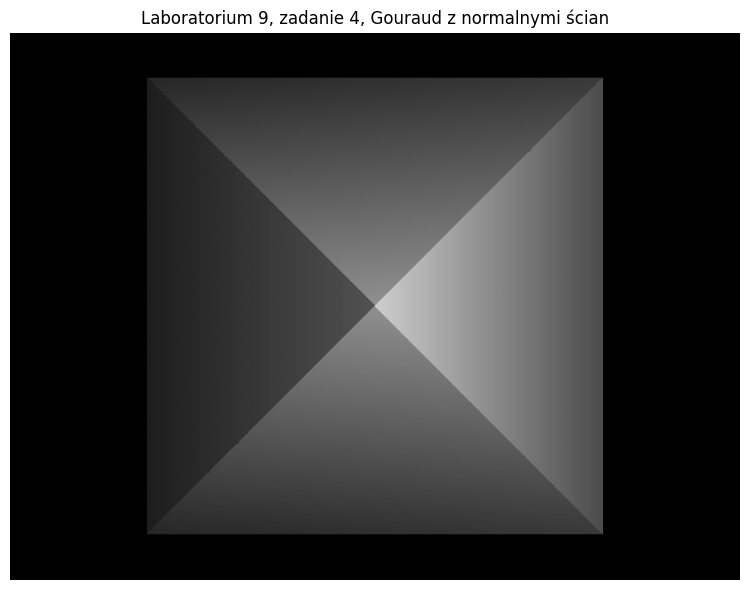

Gouraud z normalnymi ścian: min = 29.57, max = 205.46, średnia = 81.42, liczba widocznych pikseli = 160000


In [5]:
lab9_gouraud_original_result = render_scene(
    TRIANGLE_SAMPLES,
    light_position=LIGHT_POSITION,
    shading_mode="gouraud",
    lighting_model="lambert",
    corner_normals=ORIGINAL_CORNER_NORMALS,
)
show_render(lab9_gouraud_original_result, "Laboratorium 9, zadanie 4, Gouraud z normalnymi ścian")
summarize_render("Gouraud z normalnymi ścian", lab9_gouraud_original_result)

### Wnioski
Gouraud z oryginalnymi normalnymi ścian daje płynniejsze przejścia niż cieniowanie stałe, ale nadal zachowuje ostre różnice między sąsiednimi trójkątami.
Ponieważ interpolowana jest gotowa jasność wierzchołków, wynik stanowi przybliżenie pełnego modelu Lambertowskiego liczonego w każdym pikselu.

## Zadanie 5.
Ponownie stosuję cieniowanie Gourauda, ale w wierzchołkach używam średnich normalnych ścian stykających się w danym punkcie.
Taka normalna wygładza przejścia między sąsiednimi ścianami, ponieważ opisuje lokalny kierunek powierzchni po uwzględnieniu wszystkich incydentnych trójkątów.

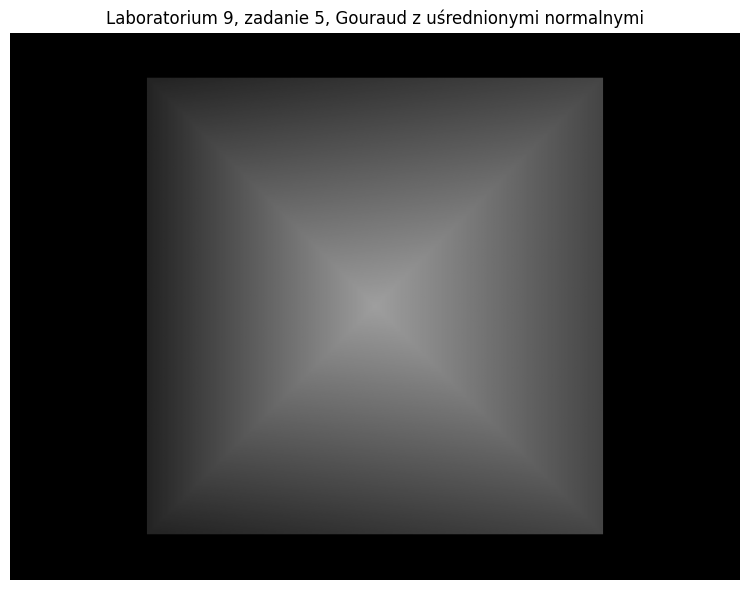

Gouraud z uśrednionymi normalnymi: min = 35.24, max = 158.25, średnia = 87.33, liczba widocznych pikseli = 160000


In [6]:
lab9_gouraud_smooth_result = render_scene(
    TRIANGLE_SAMPLES,
    light_position=LIGHT_POSITION,
    shading_mode="gouraud",
    lighting_model="lambert",
    corner_normals=SMOOTH_CORNER_NORMALS,
)
show_render(lab9_gouraud_smooth_result, "Laboratorium 9, zadanie 5, Gouraud z uśrednionymi normalnymi")
summarize_render("Gouraud z uśrednionymi normalnymi", lab9_gouraud_smooth_result)

### Wnioski
Uśrednione normalne redukują widoczne załamania między ścianami, więc obraz wygląda bardziej miękko niż przy normalnych przypisanych osobno do każdej ściany.
Jednocześnie interpolacja jasności nadal ma charakter aproksymacyjny, dlatego lokalne maksima i minima są słabiej odwzorowane niż przy liczeniu w każdym pikselu.

## Zadanie 6.
Generuję obraz z cieniowaniem Phonga, interpolując uśrednione normalne w każdym pikselu i licząc oświetlenie modelem Lamberta.
Takie podejście zachowuje gładkość wynikającą z normalnych wierzchołkowych, ale unika uproszczenia obecnego w interpolacji samych jasności.

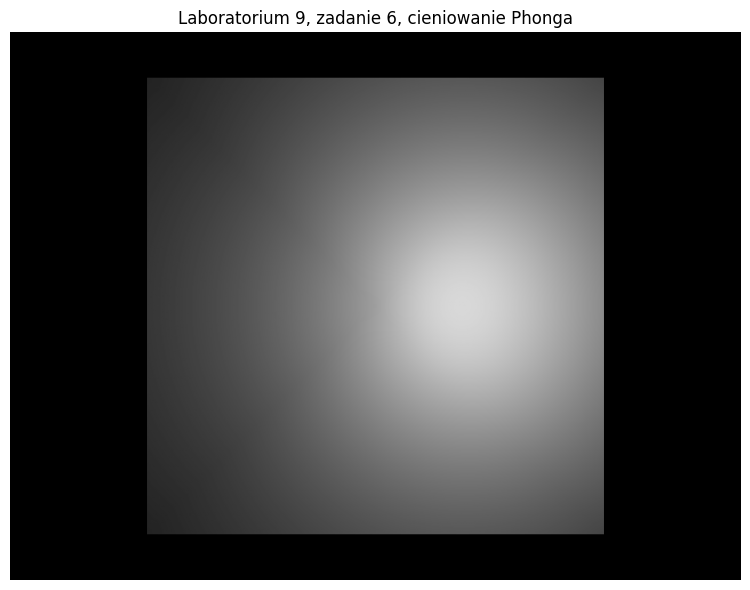

Cieniowanie Phonga z uśrednionymi normalnymi: min = 35.06, max = 215.81, średnia = 110.62, liczba widocznych pikseli = 160000


In [7]:
lab9_phong_shading_result = render_scene(
    TRIANGLE_SAMPLES,
    light_position=LIGHT_POSITION,
    shading_mode="phong",
    lighting_model="lambert",
    corner_normals=SMOOTH_CORNER_NORMALS,
)
show_render(lab9_phong_shading_result, "Laboratorium 9, zadanie 6, cieniowanie Phonga")
summarize_render("Cieniowanie Phonga z uśrednionymi normalnymi", lab9_phong_shading_result)

### Wnioski
Cieniowanie Phonga z interpolacją normalnych daje najgładszy obraz spośród zastosowanych metod, ponieważ kierunek normalnej jest aktualizowany osobno w każdym pikselu.
Dzięki temu model Lamberta reaguje na lokalne zmiany orientacji dokładniej niż w cieniowaniu Gourauda, a przejścia między ścianami są bardziej naturalne.